In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ==========================================
# 1. LOAD DATA & INITIAL FILTERING (DOMAIN KNOWLEDGE)
# ==========================================
print("--- Memuat Data ---")
df = pd.read_csv(r'/home/sony/Downloads/misah_dataset/prosperLoanData.csv')
y = df['LoanOriginalAmount'] # Tentukan Target

# Membuang fitur yang bukan prediktor valid (Data Leakage, ID, Tanggal)
kolom_dibuang = [
    'LoanOriginalAmount', # Target dipisah
    'ListingKey', 'ListingNumber', 'LoanKey', 'MemberKey', 'GroupKey', # IDs
    'ListingCreationDate', 'ClosedDate', 'DateCreditPulled', 'FirstRecordedCreditLine', 'LoanOriginationDate', 'LoanOriginationQuarter', # Dates
    'MonthlyLoanPayment', 'LP_CustomerPayments', 'LP_CustomerPrincipalPayments', 'LP_InterestandFees', 'LP_ServiceFees', 'LP_CollectionFees', 'LP_GrossPrincipalLoss', 'LP_NetPrincipalLoss', 'LP_NonPrincipalRecoverypayments', # Data Leakage (baru ada setelah disetujui)
    'LoanCurrentDaysDelinquent', 'LoanFirstDefaultedCycleNumber', 'LoanMonthsSinceOrigination' # Informasi berjalannya pinjaman
]
X = df.drop(columns=kolom_dibuang, errors='ignore')

# Membuang kolom yang persentase datanya kosong lebih dari 50%
threshold = 0.5 
X.dropna(thresh=X.shape[0] * threshold, axis=1, inplace=True)

print(f"Sisa kolom setelah membuang Data Leakage, ID, & Banyak Kosong: {X.shape[1]} kolom")

# ==========================================
# 2. PREPROCESSING (IMPUTASI & ENCODING UNTUK SEMUA SISA KOLOM)
# ==========================================
print("\n--- Melakukan Imputasi & Encoding ---")
kolom_numerik = X.select_dtypes(include=['float64', 'int64']).columns
kolom_kategori = X.select_dtypes(include=['object', 'bool']).columns

# Imputasi
imputer_num = SimpleImputer(strategy='median')
X[kolom_numerik] = imputer_num.fit_transform(X[kolom_numerik])

imputer_cat = SimpleImputer(strategy='most_frequent')
X[kolom_kategori] = imputer_cat.fit_transform(X[kolom_kategori])

# Encoding (Mengubah semua teks ke angka)
encoder = LabelEncoder()
for col in kolom_kategori:
    X[col] = encoder.fit_transform(X[col].astype(str))

# ==========================================
# 3. FEATURE SELECTION (MENGGUNAKAN MATEMATIKA / ALGORITMA)
# ==========================================

# A. PEARSON CORRELATION
print("\n--- Feature Selection: Pearson Correlation ---")
X_temp = X.copy()
X_temp['TARGET_LoanAmount'] = y.values
korelasi = X_temp.corr(method='pearson')['TARGET_LoanAmount'].drop('TARGET_LoanAmount')

# Urutkan berdasarkan korelasi absolut tertinggi (baik positif maupun negatif)
korelasi_terbaik = korelasi.abs().sort_values(ascending=False)
print("10 Fitur Terbaik Berdasarkan Pearson Correlation:")
print(korelasi.loc[korelasi_terbaik.head(10).index])

# B. LINEAR DISCRIMINANT ANALYSIS (LDA)
print("\n--- Feature Selection: LDA ---")
# Ubah target menjadi klasifikasi limit pinjaman
batas = [0, 5000, 15000, np.inf]
label_kelas = ['Rendah', 'Sedang', 'Tinggi']
y_klasifikasi = pd.cut(y, bins=batas, labels=label_kelas)

# Standarisasi (syarat wajib LDA karena range angka antar kolom berbeda-beda)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y_klasifikasi)

print(f"Dimensi data awal: {X_scaled.shape}")
print(f"Dimensi data setelah reduksi dengan LDA: {X_lda.shape}")
print(f"Informasi varians yang terselamatkan oleh 2 fitur LDA: {sum(lda.explained_variance_ratio_)*100:.2f}%")

--- Memuat Data ---
Sisa kolom setelah membuang Data Leakage, ID, & Banyak Kosong: 48 kolom

--- Melakukan Imputasi & Encoding ---

--- Feature Selection: Pearson Correlation ---
10 Fitur Terbaik Berdasarkan Pearson Correlation:
Investors                  0.380093
ProsperRating (numeric)    0.376690
ProsperRating (Alpha)     -0.370935
EstimatedLoss             -0.354757
LoanNumber                 0.350870
CreditScoreRangeUpper      0.340440
CreditScoreRangeLower      0.340440
Term                       0.338927
BorrowerRate              -0.328960
LenderYield               -0.328455
Name: TARGET_LoanAmount, dtype: float64

--- Feature Selection: LDA ---
Dimensi data awal: (113937, 48)
Dimensi data setelah reduksi dengan LDA: (113937, 2)
Informasi varians yang terselamatkan oleh 2 fitur LDA: 100.00%


In [1]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


1. MEMUAT DATA & REPRODUKSI PREPROCESSING
2. FEATURE SELECTION (TOP 10 FITUR)
Fitur terpilih untuk dievaluasi:
['Investors', 'ProsperRating (numeric)', 'ProsperRating (Alpha)', 'EstimatedLoss', 'LoanNumber', 'CreditScoreRangeUpper', 'CreditScoreRangeLower', 'Term', 'BorrowerRate', 'LenderYield']

3. STATISTIK DESKRIPTIF (MEAN, MEDIAN, MODUS, NORMALITAS)


,Fitur,Mean,Median,Modus,Skewness,Status Normalitas
0,Investors,80.48,44.00,1.00,2.14,Distribusi Tidak Normal (Menceng Signifikan)
1,ProsperRating (numeric),4.05,4.00,4.00,-0.12,Distribusi Mendekati Normal (Simetris)
2,ProsperRating (Alpha),2.87,3.00,3.00,-0.13,Distribusi Mendekati Normal (Simetris)
3,EstimatedLoss,0.08,0.07,0.07,1.01,Distribusi Tidak Normal (Menceng Signifikan)
4,LoanNumber,69444.47,68599.00,126059.00,-0.01,Distribusi Mendekati Normal (Simetris)
5,CreditScoreRangeUpper,704.54,699.00,699.00,-1.59,Distribusi Tidak Normal (Menceng Signifikan)
6,CreditScoreRangeLower,685.54,680.00,680.00,-1.59,Distribusi Tidak Normal (Menceng Signifikan)
7,Term,40.83,36.00,36.00,0.96,Distribusi Moderat (Sedikit Menceng)
8,BorrowerRate,0.19,0.18,0.32,0.28,Distribusi Mendekati Normal (Simetris)
9,LenderYield,0.18,0.17,0.31,0.29,Distribusi Mendekati Normal (Simetris)



4. VISUALISASI PERSEBARAN DATA


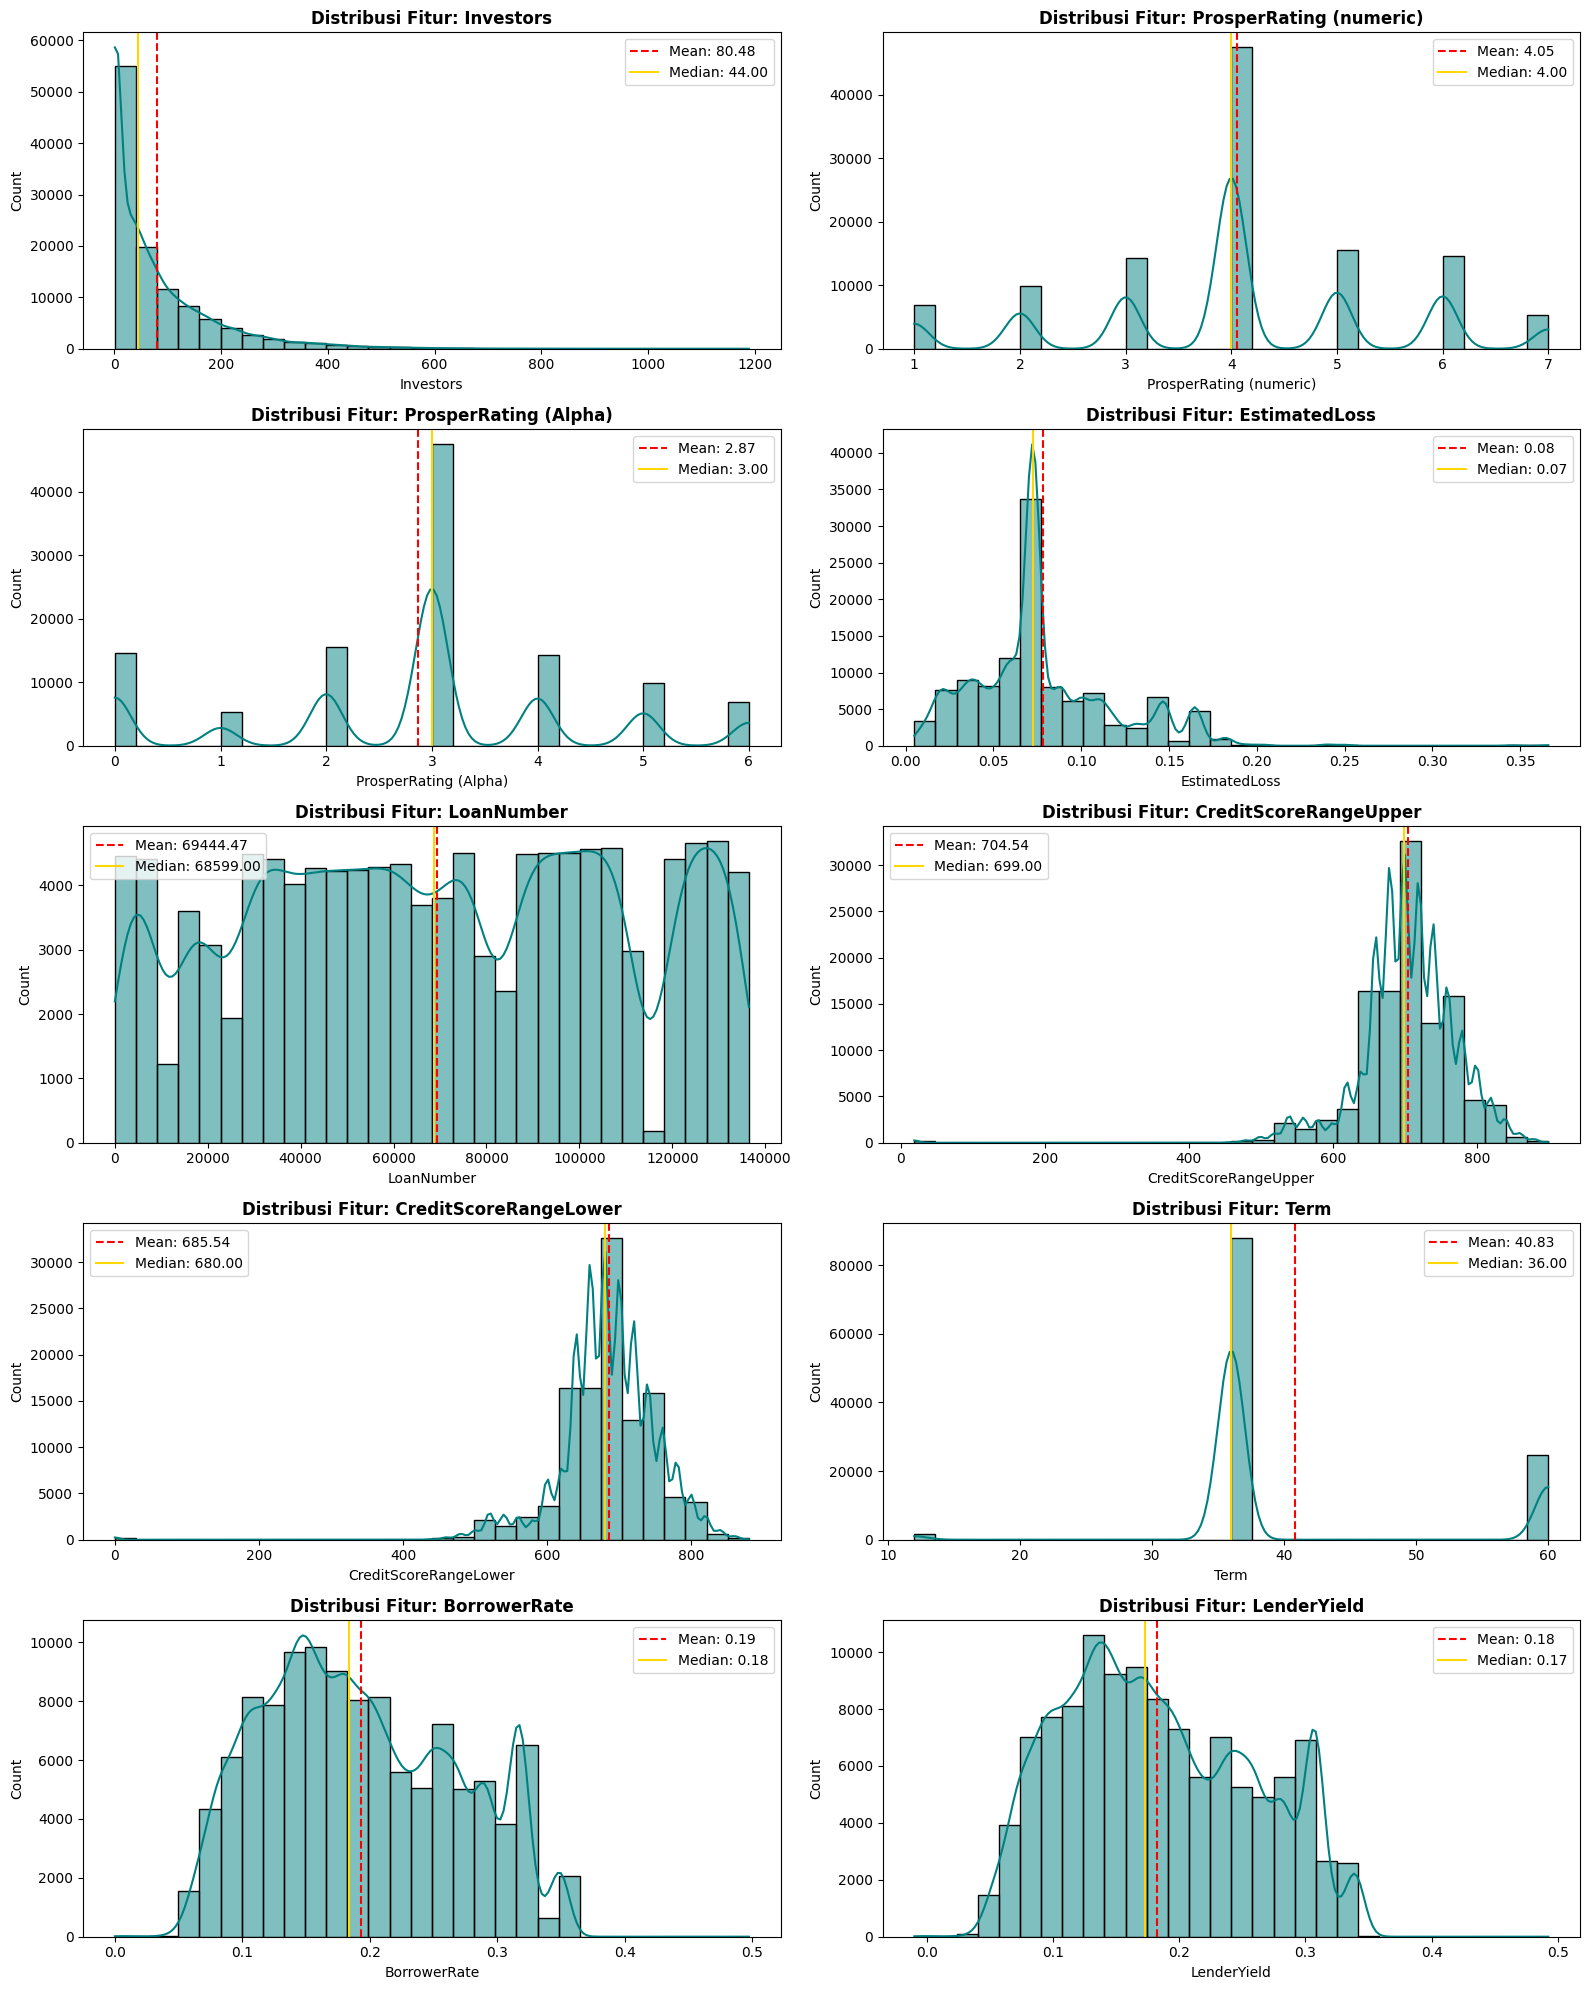

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("==================================================")
print("1. MEMUAT DATA & REPRODUKSI PREPROCESSING")
print("==================================================")
# Sesuaikan path jika perlu
df = pd.read_csv('/home/sony/Downloads/misah_dataset/prosperLoanData.csv')
y = df['LoanOriginalAmount']

# Filter Data Leakage & IDs sesuai pipeline utama
kolom_dibuang = [
    'LoanOriginalAmount', 'ListingKey', 'ListingNumber', 'LoanKey', 'MemberKey', 'GroupKey',
    'ListingCreationDate', 'ClosedDate', 'DateCreditPulled', 'FirstRecordedCreditLine', 
    'LoanOriginationDate', 'LoanOriginationQuarter',
    'MonthlyLoanPayment', 'LP_CustomerPayments', 'LP_CustomerPrincipalPayments', 
    'LP_InterestandFees', 'LP_ServiceFees', 'LP_CollectionFees', 'LP_GrossPrincipalLoss', 
    'LP_NetPrincipalLoss', 'LP_NonPrincipalRecoverypayments',
    'LoanCurrentDaysDelinquent', 'LoanFirstDefaultedCycleNumber', 'LoanMonthsSinceOrigination'
]
X = df.drop(columns=kolom_dibuang, errors='ignore')
X.dropna(thresh=X.shape[0] * 0.5, axis=1, inplace=True)

# Imputasi & Encoding
kolom_numerik = X.select_dtypes(include=['float64', 'int64']).columns
kolom_kategori = X.select_dtypes(include=['object', 'bool']).columns

X[kolom_numerik] = SimpleImputer(strategy='median').fit_transform(X[kolom_numerik])
X[kolom_kategori] = SimpleImputer(strategy='most_frequent').fit_transform(X[kolom_kategori])

encoder = LabelEncoder()
for col in kolom_kategori:
    X[col] = encoder.fit_transform(X[col].astype(str))

print("==================================================")
print("2. FEATURE SELECTION (TOP 10 FITUR)")
print("==================================================")
X_temp = X.copy()
X_temp['TARGET'] = y.values
korelasi = X_temp.corr(method='pearson')['TARGET'].drop('TARGET')

# Mengambil 10 fitur dengan korelasi absolut tertinggi
top_10_fitur = korelasi.abs().sort_values(ascending=False).head(10).index.tolist()
print(f"Fitur terpilih untuk dievaluasi:\n{top_10_fitur}")

print("\n==================================================")
print("3. STATISTIK DESKRIPTIF (MEAN, MEDIAN, MODUS, NORMALITAS)")
print("==================================================")
stats_list = []

for col in top_10_fitur:
    mean_val = X[col].mean()
    median_val = X[col].median()
    mode_val = X[col].mode()[0]
    skewness = X[col].skew()
    
    # Kriteria Normalitas berdasarkan Skewness
    if abs(skewness) <= 0.5:
        dist_status = "Distribusi Mendekati Normal (Simetris)"
    elif abs(skewness) <= 1.0:
        dist_status = "Distribusi Moderat (Sedikit Menceng)"
    else:
        dist_status = "Distribusi Tidak Normal (Menceng Signifikan)"
        
    stats_list.append({
        'Fitur': col,
        'Mean': round(mean_val, 2),
        'Median': round(median_val, 2),
        'Modus': round(mode_val, 2),
        'Skewness': round(skewness, 2),
        'Status Normalitas': dist_status
    })

df_stats = pd.DataFrame(stats_list)
display(df_stats) # Gunakan print(df_stats.to_string()) jika tidak jalan di Jupyter

print("\n==================================================")
print("4. VISUALISASI PERSEBARAN DATA")
print("==================================================")
# Membuat grid subplot untuk 10 fitur
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(top_10_fitur):
    sns.histplot(X[col], kde=True, ax=axes[i], color='teal', bins=30)
    
    # Menambahkan garis vertikal untuk Mean dan Median
    axes[i].axvline(X[col].mean(), color='red', linestyle='--', label=f'Mean: {X[col].mean():.2f}')
    axes[i].axvline(X[col].median(), color='gold', linestyle='-', label=f'Median: {X[col].median():.2f}')
    
    axes[i].set_title(f'Distribusi Fitur: {col}', fontsize=12, fontweight='bold')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
# Import modul regresi dari PyCaret
from pycaret.regression import setup, compare_models, pull, save_model

# ==========================================
# 1. LOAD DATA & INITIAL FILTER (SESUAI HASIL SEBELUMNYA)
# ==========================================
print("--- Memuat Data & Membersihkan Kolom ---")
df = pd.read_csv(r'/home/sony/Downloads/misah_dataset/prosperLoanData.csv')

kolom_dibuang = [
    'ListingKey', 'ListingNumber', 'LoanKey', 'MemberKey', 'GroupKey',
    'ListingCreationDate', 'ClosedDate', 'DateCreditPulled', 'FirstRecordedCreditLine', 
    'LoanOriginationDate', 'LoanOriginationQuarter',
    'MonthlyLoanPayment', 'LP_CustomerPayments', 'LP_CustomerPrincipalPayments', 
    'LP_InterestandFees', 'LP_ServiceFees', 'LP_CollectionFees', 'LP_GrossPrincipalLoss', 
    'LP_NetPrincipalLoss', 'LP_NonPrincipalRecoverypayments',
    'LoanCurrentDaysDelinquent', 'LoanFirstDefaultedCycleNumber', 'LoanMonthsSinceOrigination'
]

# Terapkan filter pembuangan kolom dan threshold missing value
df_clean = df.drop(columns=kolom_dibuang, errors='ignore')
df_clean.dropna(thresh=df_clean.shape[0] * 0.5, axis=1, inplace=True)

# ==========================================
# 2. SETUP PYCARET (MENGGANTIKAN MANUAL FEATURE ENGINEERING)
# ==========================================
print("\n--- Inisialisasi Environment PyCaret ---")
# Fungsi setup() akan otomatis melakukan split data (70:30), 
# imputasi median (numerik) & modus (kategori), One-Hot/Label Encoding, dan standarisasi.
regresi_eksperimen = setup(
    data=df_clean, 
    target='LoanOriginalAmount', 
    session_id=42,             # Seed untuk reproduksibilitas (hasil tidak berubah-ubah)
    imputation_type='simple',
    numeric_imputation='median',
    categorical_imputation='mode',
    normalize=True,            # Otomatis menggunakan StandardScaler
    n_jobs=-1                  # Memanfaatkan seluruh core CPU agar training cepat
)

# ==========================================
# 3. TRAINING DAN KOMPARASI SEMUA MODEL REGRESI
# ==========================================
print("\n--- Memulai Training & Komparasi Seluruh Model ---")
print("Catatan: Dataset memiliki 113.000+ baris. Proses ini memakan waktu beberapa menit.")

# compare_models akan melatih algoritma seperti XGBoost, LightGBM, Random Forest, dll.
# Parameter n_select=5 berarti kita menginstruksikan PyCaret untuk langsung 
# mengembalikan 5 model dengan metrik evaluasi terbaik (diurutkan berdasarkan R2).
top_5_models = compare_models(n_select=5, sort='R2')

# ==========================================
# 4. MENAMPILKAN HASIL DAN MENYIMPAN MODEL
# ==========================================
print("\n--- Tabel Hasil Performa Keseluruhan ---")
# pull() mengambil tabel metrik hasil compare_models terakhir
tabel_evaluasi = pull()
print(tabel_evaluasi.head(10)) 

print("\n--- 5 Model Regresi Terbaik ---")
for i, model in enumerate(top_5_models):
    print(f"Peringkat {i+1}: {model.__class__.__name__}")

# (Opsional) Menggabungkan (Blending) kelima model terbaik untuk performa maksimal
# blended_model = blend_models(estimator_list=top_5_models)

# Menyimpan model peringkat 1 ke dalam format Pickle (.pkl)
# Ini siap digunakan untuk tahap deployment / MLOps nantinya (misal menggunakan FastAPI & Gradio)
print("\n--- Menyimpan Model Terbaik ---")
save_model(top_5_models[0], 'model_prediksi_limit_terbaik')

--- Memuat Data & Membersihkan Kolom ---

--- Inisialisasi Environment PyCaret ---


,Description,Value
0,Session id,42
1,Target,LoanOriginalAmount
2,Target type,Regression
3,Original data shape,"(113937, 49)"
4,Transformed data shape,"(113937, 80)"
5,Transformed train set shape,"(79755, 80)"
6,Transformed test set shape,"(34182, 80)"
7,Numeric features,39
8,Categorical features,6
9,Rows with missing values,33.1%



--- Memulai Training & Komparasi Seluruh Model ---
Catatan: Dataset memiliki 113.000+ baris. Proses ini memakan waktu beberapa menit.


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,2106.9653,9217197.0369,3035.7835,0.7637,0.4016,0.3584,84.6710
et,Extra Trees Regressor,2053.1966,9271403.2398,3044.6487,0.7623,0.3946,0.3497,91.3010
rf,Random Forest Regressor,2043.6816,9279684.9315,3046.1082,0.7620,0.3905,0.3434,159.9480
gbr,Gradient Boosting Regressor,2455.0836,12047260.9263,3470.7643,0.6911,0.4656,0.4336,51.6790
br,Bayesian Ridge,3010.5197,16610331.3038,4075.4218,0.5741,0.6316,0.5570,2.9200
lasso,Lasso Regression,3010.0032,16609798.3091,4075.3584,0.5741,0.6327,0.5565,15.6240
ridge,Ridge Regression,3010.7007,16609552.3675,4075.3291,0.5741,0.6314,0.5568,1.7590
lr,Linear Regression,3011.2055,16614012.7283,4075.8766,0.5740,0.6304,0.5570,4.9280
llar,Lasso Least Angle Regression,3051.4761,17279528.4323,4156.3194,0.5570,0.6126,0.5688,1.7480
huber,Huber Regressor,2933.4694,17326458.3517,4162.2849,0.5558,0.5951,0.4933,5.5710



--- Tabel Hasil Performa Keseluruhan ---
                                    Model        MAE           MSE       RMSE  \
lightgbm  Light Gradient Boosting Machine  2106.9653  9.217197e+06  3035.7835   
et                  Extra Trees Regressor  2053.1966  9.271403e+06  3044.6487   
rf                Random Forest Regressor  2043.6816  9.279685e+06  3046.1082   
gbr           Gradient Boosting Regressor  2455.0836  1.204726e+07  3470.7643   
br                         Bayesian Ridge  3010.5197  1.661033e+07  4075.4218   
lasso                    Lasso Regression  3010.0032  1.660980e+07  4075.3584   
ridge                    Ridge Regression  3010.7007  1.660955e+07  4075.3291   
lr                      Linear Regression  3011.2055  1.661401e+07  4075.8766   
llar         Lasso Least Angle Regression  3051.4761  1.727953e+07  4156.3194   
huber                     Huber Regressor  2933.4694  1.732646e+07  4162.2849   

              R2   RMSLE    MAPE  TT (Sec)  
lightgbm  0.7637  0.4

(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['Term', 'BorrowerAPR',
                                              'BorrowerRate', 'LenderYield',
                                              'EstimatedEffectiveYield',
                                              'EstimatedLoss', 'EstimatedReturn',
                                              'ProsperRating (numeric)',
                                              'ProsperScore',
                                              'ListingCategory (numeric)',
                                              'EmploymentStatusDuration',
                                              'CreditScoreRangeLower',
                                              'CreditScoreRangeUpper',
                                              'Cur...
                 ('rest_encoding',
                  TransformerWrapper(include=['BorrowerState', 'Occupation'],
                           

In [9]:
import pandas as pd
import numpy as np
import joblib

# Sklearn Tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# 5 Algoritma Regresi (Sesuai hasil evaluasi sebelumnya)
from lightgbm import LGBMRegressor 
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import BayesianRidge

print("==================================================")
print("1. MEMUAT DATA & PEMBERSIHAN AWAL (DATA LEAKAGE)")
print("==================================================")
df = pd.read_csv(r'/home/sony/Downloads/misah_dataset/prosperLoanData.csv')
y = df['LoanOriginalAmount'] # Tentukan Target

# Membuang fitur data leakage, IDs, dan Tanggal
kolom_dibuang = [
    'LoanOriginalAmount', 'ListingKey', 'ListingNumber', 'LoanKey', 'MemberKey', 'GroupKey',
    'ListingCreationDate', 'ClosedDate', 'DateCreditPulled', 'FirstRecordedCreditLine', 
    'LoanOriginationDate', 'LoanOriginationQuarter',
    'MonthlyLoanPayment', 'LP_CustomerPayments', 'LP_CustomerPrincipalPayments', 
    'LP_InterestandFees', 'LP_ServiceFees', 'LP_CollectionFees', 'LP_GrossPrincipalLoss', 
    'LP_NetPrincipalLoss', 'LP_NonPrincipalRecoverypayments',
    'LoanCurrentDaysDelinquent', 'LoanFirstDefaultedCycleNumber', 'LoanMonthsSinceOrigination'
]
X = df.drop(columns=kolom_dibuang, errors='ignore')

# Membuang kolom yang dominan kosong (>50% missing)
X.dropna(thresh=X.shape[0] * 0.5, axis=1, inplace=True)

print("==================================================")
print("2. IMPUTASI & ENCODING (MANUAL PREPROCESSING)")
print("==================================================")
# Memisahkan mana kolom angka dan teks
kolom_numerik = X.select_dtypes(include=['float64', 'int64']).columns
kolom_kategori = X.select_dtypes(include=['object', 'bool']).columns

# Mengisi data kosong (Imputasi)
X[kolom_numerik] = SimpleImputer(strategy='median').fit_transform(X[kolom_numerik])
X[kolom_kategori] = SimpleImputer(strategy='most_frequent').fit_transform(X[kolom_kategori])

# Mengubah teks menjadi angka (Label Encoding)
encoder = LabelEncoder()
for col in kolom_kategori:
    X[col] = encoder.fit_transform(X[col].astype(str))

# Membagi Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data siap dilatih. Jumlah Data Train: {X_train.shape[0]} baris.")

print("\n==================================================")
print("3. MEMULAI PELATIHAN 5 MODEL TERBAIK")
print("==================================================")

# Membuat Pipeline untuk 5 Model
pipelines = {
    "LightGBM": Pipeline([('scaler', StandardScaler()), ('model', LGBMRegressor(random_state=42, n_jobs=-1))]),
    "Extra Trees": Pipeline([('scaler', StandardScaler()), ('model', ExtraTreesRegressor(random_state=42, n_jobs=-1))]),
    "Random Forest": Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))]),
    "Gradient Boosting": Pipeline([('scaler', StandardScaler()), ('model', GradientBoostingRegressor(random_state=42))]),
    "Bayesian Ridge": Pipeline([('scaler', StandardScaler()), ('model', BayesianRidge())])
}

hasil_evaluasi = []

# Loop untuk training dan evaluasi
for nama_model, pipeline in pipelines.items():
    print(f">> Sedang melatih {nama_model}...")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Simpan Skor
    hasil_evaluasi.append({
        'Model': nama_model,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
        'Pipeline_Objek': pipeline
    })

print("\n==================================================")
print("4. REKAPITULASI HASIL & PENYIMPANAN MODEL MLOPS")
print("==================================================")

df_hasil = pd.DataFrame(hasil_evaluasi).sort_values(by='R2', ascending=False).reset_index(drop=True)
print(df_hasil[['Model', 'MAE', 'RMSE', 'R2']])

# Ekstrak & Simpan Model Terbaik
model_terbaik_nama = df_hasil.loc[0, 'Model']
model_terbaik_obj = df_hasil.loc[0, 'Pipeline_Objek']

joblib.dump(model_terbaik_obj, 'master_pipeline_limit_pinjaman.pkl')
print(f"\n✅ SUKSES! Model '{model_terbaik_nama}' berhasil disimpan sebagai 'master_pipeline_limit_pinjaman.pkl'.")

1. MEMUAT DATA & PEMBERSIHAN AWAL (DATA LEAKAGE)
2. IMPUTASI & ENCODING (MANUAL PREPROCESSING)
Data siap dilatih. Jumlah Data Train: 91149 baris.

3. MEMULAI PELATIHAN 5 MODEL TERBAIK
>> Sedang melatih LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033601 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5108
[LightGBM] [Info] Number of data points in the train set: 91149, number of used features: 48
[LightGBM] [Info] Start training from score 8342.928194
>> Sedang melatih Extra Trees...
>> Sedang melatih Random Forest...
>> Sedang melatih Gradient Boosting...
>> Sedang melatih Bayesian Ridge...

4. REKAPITULASI HASIL & PENYIMPANAN MODEL MLOPS
               Model          MAE         RMSE        R2
0        Extra Trees  2003.321017  2992.130336  0.768906
1      Random Forest  2016.242800  3010.769792  0.766018
2           Li